Scratch cells for initial solenoid tests. Will probably become more sophisticated as time goes on.

In [1]:
from g4beam import *
from scan import *
from cpymad.madx import Madx
import scipy

In [2]:
# Useful function that handles lists of distributions
# Should probably be included in g4beam.py eventually

def df_list_to_table(particles_list):
    z_list = [df.z[0] for df in particles_list]
    res = list()
    for z, df in zip(z_list, particles_list):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

In [3]:
# Generate a distribution and run it

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.8    # m
beta_y = 1.8    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
# write_trackfile(particles_before, "solenoid_particles_before.txt")
particles_after_list = run_g4beam(particles_before, "G4_SolenoidTest.g4bl",
                                  multioutput=["s"] + [str(x) for x in range(11)] + ["f"],
                                  maxStep=0.1)

In [14]:
particles_after_list = particles_after_list[:-1]

In [15]:
test_data = df_list_to_table(particles_after_list)

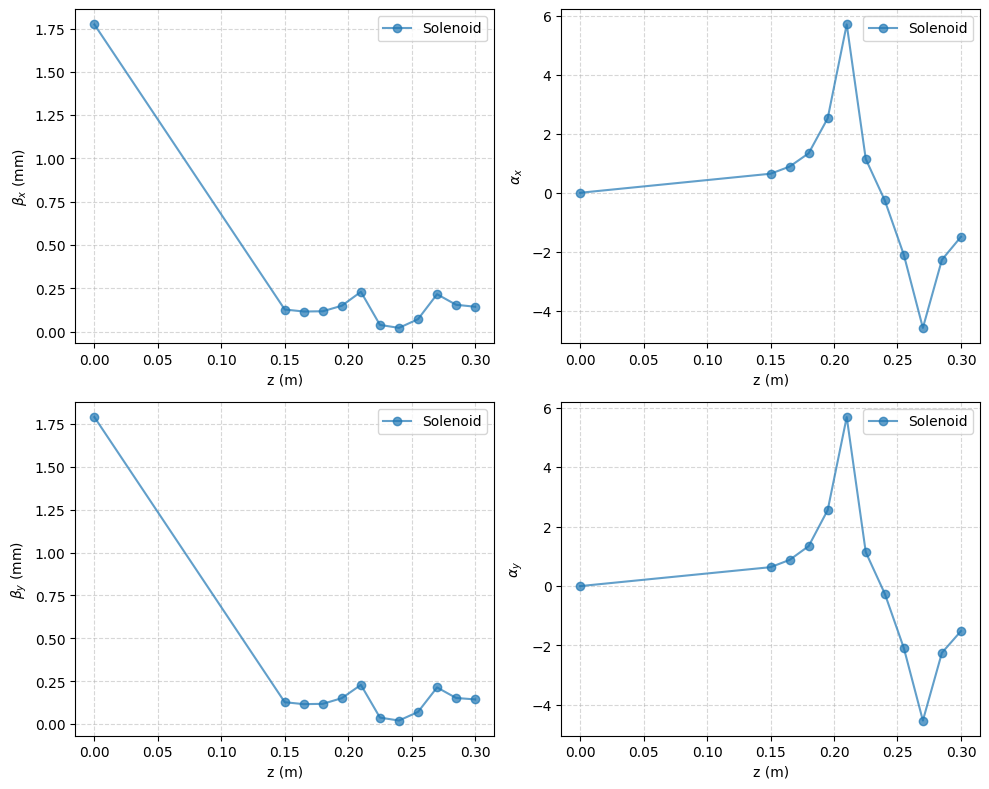

In [16]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(test_data["z"], test_data[col], label="Solenoid", marker='o', linestyle='-', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
# plt.savefig("???")
plt.show()